# Latency Benchmark - RAG vs Full-Context

Measures where a chatbot turn actually spends its time, and whether retrieval made it faster.

A turn has three stages, and RAG affects each differently:

| Stage | Cost | Effect of RAG |
|---|---|---|
| **1. Retrieval** | 1 Gemini embedding call + a Chroma query | **added** - full-context has no retrieval at all |
| **2. Answer** | 1 Gemini call | **faster** - a 6-section prompt prefills quicker than the whole document |
| **3. Verification** | 1 Gemini call, always reads the **full** docs | **unchanged** - `grounding.verify()` ignores `USE_RAG` |

So RAG can only win on stage 2, while paying for stage 1, and stage 3 is untouched by design.
If a measurement shows stage 3 moving, the run was noisy - not that retrieval helped.

**What you feel in the app is not total latency.** `assistant/session.py` streams the answer
via `bot.respond_stream()`, and verification runs afterwards in `finalize_answer()`. So the
perceived speed is **time-to-first-token** (stage 1 + stage 2's prefill) - which is exactly
where RAG helps most. This notebook reports TTFT separately for that reason.

**This notebook is resumable.** Every completed turn is appended to a log the moment it
finishes, so running out of quota mid-run costs you nothing. Re-run the run cell when quota
resets and it picks up exactly where it stopped.

## Flag reference - when to set what

### Environment flags

| Flag | Set to | When and why |
|---|---|---|
| `LLM_CACHE` | **`0`** | **Always, when timing anything.** Left at `1`, any prompt you have sent before returns from `logs/llm_cache.sqlite` in ~0 ms and every number below is fiction. This is the single most common way to fool yourself. |
| | `1` | Normal app use, and re-running the *eval* harness cheaply over unchanged prompts. Never while timing. |
| `LLM_OFFLINE` | **`0`** | Always here. `1` raises on a cache miss instead of calling out - useful for building a harness, useless for timing one. |
| `LLM_BACKEND` | **`gemini`** | Real latency. The only setting that produces meaningful numbers. |
| | `mock` | Smoke-testing that this notebook *runs* without spending quota. Timings are meaningless - there is no network call. |
| `USE_RAG` | *(both)* | Do not set this by hand. The benchmark A/Bs `1` and `0` over the identical question set, so model and network conditions are shared. |
| `VECTOR_BACKEND` | **`chroma`** | The production index. |
| | `memory` | Only when comparing the two index backends against each other - not for a RAG-vs-full comparison. |
| `VERIFY_ANSWERS` | *(not read)* | This notebook times verification as its own stage via `MEASURE_VERIFY` below, rather than letting `bot.respond()` fold it into one number. |

### Notebook knobs

| Knob | Default | Meaning |
|---|---|---|
| `QUESTIONS` | 5 questions | The question set. Add to it over time - already-measured questions are skipped automatically. |
| `REPS` | `2` | Target samples per question **per mode**. Raising it tops up existing questions rather than restarting them. |
| `MEASURE_VERIFY` | `True` | Include stage 3. Set `False` to cut roughly a third of the quota cost when you only care whether retrieval sped up the *answer*. |

### Cost

Each measured turn is **1 answer call**, plus **1 embedding call** in RAG mode, plus **1
verification call** if `MEASURE_VERIFY`. The run cell prints the exact estimate for the turns
it still needs - read it before executing on free-tier quota.

In [1]:
import difflib
import json
import random
import re
import sys
import time
from datetime import datetime
from pathlib import Path

import pandas as pd

# This notebook lives in evaluation/, so the project root is one level up.
ROOT = Path.cwd().parent if Path.cwd().name == "evaluation" else Path.cwd()
sys.path.insert(0, str(ROOT))

import config
from core import grounding, knowledge, llm, retrieval

# --- the flags that decide whether these numbers mean anything --------------
config.LLM_CACHE = False     # MUST be False. See the flag table above.
config.LLM_OFFLINE = False
config.LLM_BACKEND = "gemini"

print("backend        :", config.LLM_BACKEND)
print("cache          :", config.LLM_CACHE, "(must be False)")
print("vector backend :", config.VECTOR_BACKEND)
print("answer model   :", config.ANSWER_MODEL)
print("embed model    :", config.EMBED_MODEL)
print("RAG_TOP_K      :", config.RAG_TOP_K)

assert not config.LLM_CACHE, "LLM_CACHE is on - every timing below would be meaningless"
assert config.LLM_BACKEND == "gemini", "mock backend produces no real latency"

backend        : gemini
cache          : False (must be False)
vector backend : memory
answer model   : gemini-3.1-flash-lite
embed model    : gemini-embedding-001
RAG_TOP_K      : 6


## The question log

`evaluation/results/latency_log.csv` accumulates one row per completed turn, across every
session. It exists for two reasons:

1. **Quota exhaustion costs you nothing.** Each turn is appended the instant it finishes, not
   batched to the end of the run. If Gemini cuts you off after 12 of 40 turns, those 12 are
   already on disk. Re-run the run cell tomorrow and it measures only the missing 28.
2. **You can grow the question set over time.** Add questions to `QUESTIONS` whenever you think
   of them; anything already at `REPS` samples is skipped rather than re-measured.

### Spotting questions you have already asked

The check below is **lexical, not semantic** - it compares words, not meaning, because running
embeddings over the candidate set would cost the very quota this log exists to protect.

It scores two ways and takes the better: word-overlap (Jaccard) after dropping stopwords, which
catches reordering, and `difflib` sequence ratio, which catches small edits. So it will flag

> "How do I void a payment?" vs "How can I void payments?"

and it will **miss**

> "How do I void a payment?" vs "How do I reverse a transaction?"

which share no words but mean the same thing. That is why the cell also prints the full list of
logged questions: the score is a prompt for your judgement, not a replacement for it.

In [2]:
LOG_PATH = ROOT / "evaluation" / "results" / "latency_log.csv"
LOG_COLUMNS = [
    "logged_at", "run_id", "question", "mode", "rep",
    "retrieval_ms", "ttft_ms", "answer_ms", "verify_ms", "total_ms", "prompt_chars",
    "answer_model", "embed_model", "vector_backend", "rag_top_k", "measured_verify",
]


def load_log() -> pd.DataFrame:
    """Every turn ever measured. Empty frame on the first run."""
    if LOG_PATH.exists():
        return pd.read_csv(LOG_PATH)
    return pd.DataFrame(columns=LOG_COLUMNS)


def append_row(row: dict) -> None:
    """Append one completed turn *immediately*, so a quota stop loses nothing."""
    LOG_PATH.parent.mkdir(parents=True, exist_ok=True)
    write_header = not LOG_PATH.exists()
    pd.DataFrame([row])[LOG_COLUMNS].to_csv(
        LOG_PATH, mode="a", header=write_header, index=False
    )


# --- lexical near-duplicate detection (no embeddings) -----------------------
_STOPWORDS = {
    "how", "do", "i", "the", "a", "an", "to", "in", "on", "of", "my", "can",
    "is", "it", "for", "and", "you", "me", "what", "where", "does", "with",
}


def _content_words(question: str) -> list:
    words = re.findall(r"[a-z0-9]+", question.lower())
    return [w for w in words if w not in _STOPWORDS]


def similarity(a: str, b: str) -> float:
    """Lexical closeness, 0-1. Compares WORDS, not meaning - see the note above."""
    wa, wb = _content_words(a), _content_words(b)
    if not wa or not wb:
        return 0.0
    jaccard = len(set(wa) & set(wb)) / len(set(wa) | set(wb))
    if jaccard == 0:
        # No content word in common. The sequence ratio alone would still score
        # ~0.5 on two unrelated questions that merely share a shape ("How do I
        # ... a ...?"), so refuse to guess from letters alone.
        return 0.0
    sequence = difflib.SequenceMatcher(None, " ".join(wa), " ".join(wb)).ratio()
    return max(jaccard, sequence)


def similar_to_logged(question: str, log: pd.DataFrame, top: int = 3,
                      threshold: float = 0.55) -> list:
    """Logged questions that look like this one, best first."""
    if not len(log):
        return []
    seen = [q for q in log["question"].unique() if q != question]
    scored = sorted(((similarity(question, q), q) for q in seen), reverse=True)
    return [(q, s) for s, q in scored[:top] if s >= threshold]


print("log:", LOG_PATH.relative_to(ROOT))
print(f"{len(load_log())} rows so far")

log: evaluation\results\latency_log.csv
0 rows so far


## The question set

Pick questions whose answers live in **different** doc sections - a set that all hits one
section would flatter retrieval.

Add to this list freely between sessions. The next cell shows what is already logged and what
would actually run, before you spend anything.

In [8]:
QUESTIONS = [
    "How do I record vital signs?",
    "How do I pay the monthly subscription?",
    "How do I add a new patient?",
    "How do I create an appointment?",
]

REPS = 2               # target samples per question PER MODE
MEASURE_VERIFY = True  # False = skip stage 3 and cut the quota cost

## Pre-flight

Read this before running anything. It prints every question already in the log, flags candidates
that look like repeats, confirms your stored section embeddings will actually be reused, and
works out exactly which turns are still missing.

**On the seed.** `embeddings.json` holds the 64 section vectors you already paid for. It is used
only while its stamped fingerprint matches the current docs and embedding model, so this cell
checks that explicitly rather than letting a silent mismatch re-embed the whole document set
mid-benchmark. If it reports stale, run `python stamp_embeddings.py` before spending quota
here.

In [9]:
log = load_log()
mine = log[log["answer_model"] == config.ANSWER_MODEL] if len(log) else log

# --- what has already been measured, for your eyeball ----------------------
if len(mine):
    print(f"ALREADY LOGGED ({mine['question'].nunique()} questions, {len(mine)} samples)")
    print("read these before adding new ones:\n")
    for q, grp in mine.groupby("question"):
        by_mode = grp["mode"].value_counts().to_dict()
        print(f"  rag={by_mode.get('rag', 0)} full={by_mode.get('full', 0)}  {q}")
    print()
else:
    print("log is empty - this is the first run\n")

# --- lexical near-duplicate warnings ---------------------------------------
flagged = [(q, similar_to_logged(q, mine)) for q in QUESTIONS]
flagged = [(q, near) for q, near in flagged if near]
if flagged:
    print("POSSIBLE REPEATS - lexical only, you decide:\n")
    for q, near in flagged:
        print(f"  candidate: {q}")
        for other, score in near:
            print(f"             {score:.0%} similar to logged: {other}")
    print()

# --- exactly which turns are still missing ---------------------------------
planned = []
for q in QUESTIONS:
    for use_rag in (True, False):
        mode = "rag" if use_rag else "full"
        have = len(mine[(mine["question"] == q) & (mine["mode"] == mode)]) if len(mine) else 0
        for rep in range(have, REPS):
            planned.append((rep, use_rag, q))

# Built question-major, which would run every RAG turn before its full-context
# twin and let order masquerade as a mode difference. Unseeded on purpose: the
# bias should land somewhere different on every run instead of being fixed.
random.shuffle(planned)

# --- will the stored section embeddings be reused? -------------------------
n_sections = len(knowledge.content_sections())
seed_path = config.EMBEDDINGS_SEED_PATH
seed_applies = False

seed_fix = "`python stamp_embeddings.py` re-stamps the file if the vectors are still correct"

# Both backends read the seed: chroma persists the built index to disk, memory
# rebuilds it per process. Either way the section vectors come from the file.
if not seed_path.exists():
    seed_status = f"no seed file at {seed_path.name}"
    seed_fix = "regenerate it from the notebook, then `python stamp_embeddings.py`"
else:
    stamped = json.loads(seed_path.read_text(encoding="utf-8")).get("fingerprint")
    current = retrieval.fingerprint()
    seed_applies = stamped == current
    seed_status = (
        f"{seed_path.name} matches ({current}) - {n_sections} section vectors "
        f"come from the file, costing nothing [{config.VECTOR_BACKEND} backend]"
        if seed_applies else
        f"{seed_path.name} is stale (file {stamped}, current {current})"
    )

print("section embeddings:", seed_status)
if not seed_applies:
    print(f"  -> the first RAG turn will re-embed all {n_sections} sections "
          "(one batched request)")
    print(f"  -> {seed_fix}")
print()

# --- exactly what this will cost ------------------------------------------
rag_turns = sum(1 for _, use_rag, _ in planned if use_rag)
n_calls = len(planned) + rag_turns + (len(planned) if MEASURE_VERIFY else 0)
if rag_turns and not seed_applies:
    n_calls += 1          # the one batched section-embedding request

print(f"{len(planned)} turns still needed -> roughly {n_calls} Gemini calls")
print(f"  {len(planned)} answer" + (f" + {len(planned)} verification" if MEASURE_VERIFY else "")
      + f" + {rag_turns} query-embedding"
      + ("" if seed_applies or not rag_turns else " + 1 section-embedding rebuild"))
if not planned:
    print("nothing to do: every question already has "
          f"{REPS} samples in both modes. Add questions or raise REPS.")

log is empty - this is the first run

section embeddings: VECTOR_BACKEND='memory' keeps no persistent index, so all 64 sections are re-embedded every run
  -> the first RAG turn will re-embed all 64 sections (one batched request)
  -> set VECTOR_BACKEND='chroma' to reuse the stored vectors

16 turns still needed -> roughly 41 Gemini calls
  16 answer + 16 verification + 8 query-embedding + 1 section-embedding rebuild


## The timing harness

This mirrors what `bot.respond_stream()` does, with a `perf_counter` around each stage instead
of one number for the whole turn.

Two details that matter:

- **A fresh chat per question.** `llm.Chat` accumulates history, so reusing one chat would grow
  the prompt turn over turn and quietly confound the comparison.
- **TTFT comes from the streaming API** - the same path the widget uses - not from `send()`,
  which only returns once the whole answer is built.

In [10]:
def measure_turn(question: str, use_rag: bool, verify: bool) -> dict:
    """Time one turn, stage by stage. Mirrors bot.respond_stream()."""
    config.USE_RAG = use_rag
    row = {"question": question, "mode": "rag" if use_rag else "full"}

    # --- stage 1: retrieval (embeds the query + queries Chroma when USE_RAG) --
    t0 = time.perf_counter()
    system = knowledge.system_prompt(query=question)
    row["retrieval_ms"] = (time.perf_counter() - t0) * 1000
    row["prompt_chars"] = len(system)

    # Fresh chat, so accumulated history never inflates the prompt.
    chat = llm.new_chat(system, model=config.ANSWER_MODEL)

    # --- stage 2: answer, capturing time-to-first-token ----------------------
    t0 = time.perf_counter()
    first_token_at = None
    chunks = []
    for piece in chat.send_stream(question):
        if first_token_at is None:
            first_token_at = time.perf_counter()
        chunks.append(piece)
    done = time.perf_counter()
    row["ttft_ms"] = ((first_token_at or done) - t0) * 1000
    row["answer_ms"] = (done - t0) * 1000
    draft = "".join(chunks)

    # --- stage 3: verification (always reads the FULL docs, in both modes) ---
    if verify:
        t0 = time.perf_counter()
        grounding.verify(question, draft)
        row["verify_ms"] = (time.perf_counter() - t0) * 1000
    else:
        row["verify_ms"] = float("nan")

    row["total_ms"] = row["retrieval_ms"] + row["answer_ms"] + (
        row["verify_ms"] if verify else 0.0
    )
    return row

## Warm-up

The first RAG call builds or loads the Chroma collection, and the first call of any kind pays
TCP/TLS setup. Both land entirely on whichever sample happens to go first, and would show up as
a fake win for whichever mode ran second. These two samples are deliberately **not** logged.

In [11]:
if planned:
    retrieval.reset_index()
    _ = measure_turn(QUESTIONS[0], use_rag=True, verify=False)   # builds / loads the index
    _ = measure_turn(QUESTIONS[0], use_rag=False, verify=False)  # warms the connection
    print("warm-up done - samples discarded, not logged")
else:
    print("nothing planned; skipping warm-up")

Direct use of automatic function calling (AFC) in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream. Similarly, direct use of AFC in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message.


warm-up done - samples discarded, not logged


## Run

Safe to interrupt, and safe to run out of quota in. Each turn is written to the log as soon as
it completes, so stopping early only costs the turn in flight.

If Gemini cuts you off, the cell reports how far it got and stops cleanly - it does **not**
retry or skip ahead to another question, since a partial set measured under a throttled quota
would be worse than no measurement. Re-run this cell when quota resets.

In [12]:
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")
meta = dict(
    run_id=run_id,
    answer_model=config.ANSWER_MODEL,
    embed_model=config.EMBED_MODEL,
    vector_backend=config.VECTOR_BACKEND,
    rag_top_k=config.RAG_TOP_K,
    measured_verify=MEASURE_VERIFY,
)

completed = 0
try:
    for rep, use_rag, q in planned:
        row = measure_turn(q, use_rag=use_rag, verify=MEASURE_VERIFY)
        row.update(meta, rep=rep, logged_at=datetime.now().isoformat(timespec="seconds"))
        append_row(row)          # <- on disk now, not at the end of the loop
        completed += 1
        print(f"  rep{rep} {row['mode']:<5} {row['total_ms']:7.0f} ms  {q[:42]}")
except llm.QuotaError as exc:
    print(f"\nSTOPPED - quota exhausted after {completed}/{len(planned)} turns.")
    print("Everything measured so far is already in the log. Re-run this cell when")
    print("quota resets; the pre-flight will plan only the turns still missing.")
    print(f"  {str(exc)[:200]}")
except llm.LLMError as exc:
    print(f"\nSTOPPED - model error after {completed}/{len(planned)} turns: {str(exc)[:160]}")
except KeyboardInterrupt:
    print(f"\ninterrupted after {completed}/{len(planned)} turns - log is intact")

print(f"\n{completed} turns appended to {LOG_PATH.name}")

  rep0 rag      4820 ms  How do I record vital signs?
  rep1 rag      4756 ms  How do I record vital signs?
  rep0 full     3357 ms  How do I record vital signs?
  rep1 full     3676 ms  How do I record vital signs?
  rep0 rag      3992 ms  How do I pay the monthly subscription?
  rep1 rag      3967 ms  How do I pay the monthly subscription?
  rep0 full     3230 ms  How do I pay the monthly subscription?

STOPPED - model error after 7/16 turns: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on

7 turns appended to latency_log.csv


## Summary

Reads the **whole log** for the current answer model, not just this session - so numbers keep
tightening as you add questions across runs.

Three statistics, because the spread between them is the point:

- **median** - what a typical turn costs. This is the headline.
- **mean** - the arithmetic average. Shown mainly as a check: network latency has a long right
  tail, so one slow call drags a mean somewhere no request actually went. When mean sits far
  above median, outliers are steering it.
- **p90** - what a bad turn costs.

If the median and mean columns disagree about *which mode is faster*, you do not have a result
yet - you have noise. Add samples.

In [13]:
STAGES = ["retrieval_ms", "ttft_ms", "answer_ms", "verify_ms", "total_ms"]

df = load_log()
df = df[df["answer_model"] == config.ANSWER_MODEL]
print(f"{len(df)} samples over {df['question'].nunique()} questions "
      f"from {df['run_id'].nunique()} run(s)\n")
print(df["question"].unique(), "\n")

cols = STAGES + ["prompt_chars"]
med = df.groupby("mode")[cols].median().round(0)      # the chart cell reads this
avg = df.groupby("mode")[cols].mean().round(0)
p90 = df.groupby("mode")[STAGES].quantile(0.90).round(0)

display(pd.concat(
    {"median": med[STAGES].T, "mean": avg[STAGES].T, "p90": p90.T}, axis=1
))

if {"rag", "full"} <= set(med.index):
    print("RAG vs full-context (negative = RAG faster)")
    print(f"  {'stage':<14} {'by median':>11} {'by mean':>11}")
    for s in STAGES:
        d_med = med.loc["rag", s] - med.loc["full", s]
        d_avg = avg.loc["rag", s] - avg.loc["full", s]
        if pd.notna(d_med):
            print(f"  {s:<14} {d_med:>+11.0f} {d_avg:>+11.0f}")

    # A mean far from its median means a few slow calls are steering it. Stages
    # under 1 ms are excluded - their ratios are noise on a near-zero base.
    ratio = (avg[STAGES] / med[STAGES].where(med[STAGES] >= 1)).max().max()
    if pd.notna(ratio) and ratio > 1.25:
        print(f"\n  heads up: a mean runs {ratio:.1f}x its median somewhere above.")
        print("  Outliers are pulling it - read the median column as the headline,")
        print("  and if the two columns disagree on sign, you need more samples.")

    shrink = 1 - med.loc["rag", "prompt_chars"] / med.loc["full", "prompt_chars"]
    print(f"\n  prompt is {shrink:.1%} smaller under RAG "
          f"({med.loc['rag', 'prompt_chars']:,.0f} vs "
          f"{med.loc['full', 'prompt_chars']:,.0f} chars)")

7 samples over 2 questions from 1 run(s)

<ArrowStringArray>
['How do I record vital signs?', 'How do I pay the monthly subscription?']
Length: 2, dtype: str 



median            mean             p90        
mode            full     rag    full     rag    full     rag
retrieval_ms     0.0   484.0     0.0   481.0     0.0   526.0
ttft_ms       1251.0  1580.0  1276.0  1549.0  1397.0  1845.0
answer_ms     1922.0  2435.0  2013.0  2393.0  2186.0  2709.0
verify_ms     1424.0  1541.0  1408.0  1509.0  1433.0  1647.0
total_ms      3357.0  4374.0  3421.0  4384.0  3612.0  4801.0

RAG vs full-context (negative = RAG faster)
  stage            by median     by mean
  retrieval_ms          +484        +481
  ttft_ms               +329        +273
  answer_ms             +513        +380
  verify_ms             +117        +101
  total_ms             +1017        +963

  prompt is 90.7% smaller under RAG (2,924 vs 31,493 chars)


## Chart

Median milliseconds per stage. Read it as three separate questions:

- **Retrieval** - the cost RAG adds. Full-context should be near zero.
- **Time to first token** - what a user actually perceives, since the widget streams.
- **Verification** - should be **roughly equal in both modes**. It reads the full docs either
  way, so a large gap here means the run was noisy, not that retrieval helped.

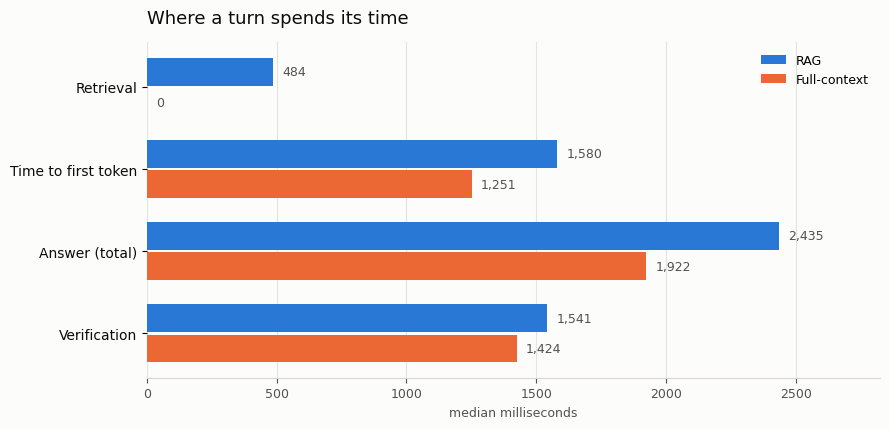

In [14]:
import matplotlib.pyplot as plt

SURFACE, INK, INK_MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
C_RAG, C_FULL = "#2a78d6", "#eb6834"   # categorical slots 1-2, CVD-validated

labels = ["Retrieval", "Time to first token", "Answer (total)", "Verification"]
keys = ["retrieval_ms", "ttft_ms", "answer_ms", "verify_ms"]
rag = [med.loc["rag", k] for k in keys]
full = [med.loc["full", k] for k in keys]
widest = max(v for v in rag + full if pd.notna(v))

y = range(len(labels))
h = 0.34
fig, ax = plt.subplots(figsize=(9, 4.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

bars_rag = ax.barh([i - h / 2 - 0.015 for i in y], rag, height=h, color=C_RAG, label="RAG")
bars_full = ax.barh([i + h / 2 + 0.015 for i in y], full, height=h, color=C_FULL,
                    label="Full-context")

for bars, vals in ((bars_rag, rag), (bars_full, full)):
    for bar, v in zip(bars, vals):
        if pd.notna(v):
            ax.text(bar.get_width() + widest * 0.015,
                    bar.get_y() + bar.get_height() / 2,
                    f"{v:,.0f}", va="center", fontsize=9, color=INK_MUTED)

ax.set_yticks(list(y), labels, fontsize=10, color=INK)
ax.invert_yaxis()   # read the pipeline top-down: retrieval -> answer -> verification
ax.set_xlabel("median milliseconds", fontsize=9, color=INK_MUTED)
ax.set_title("Where a turn spends its time", fontsize=13, color=INK, pad=14, loc="left")
ax.tick_params(axis="x", colors=INK_MUTED, labelsize=9)
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#d8d7d2")
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.set_xlim(0, widest * 1.16)
plt.tight_layout()
plt.show()

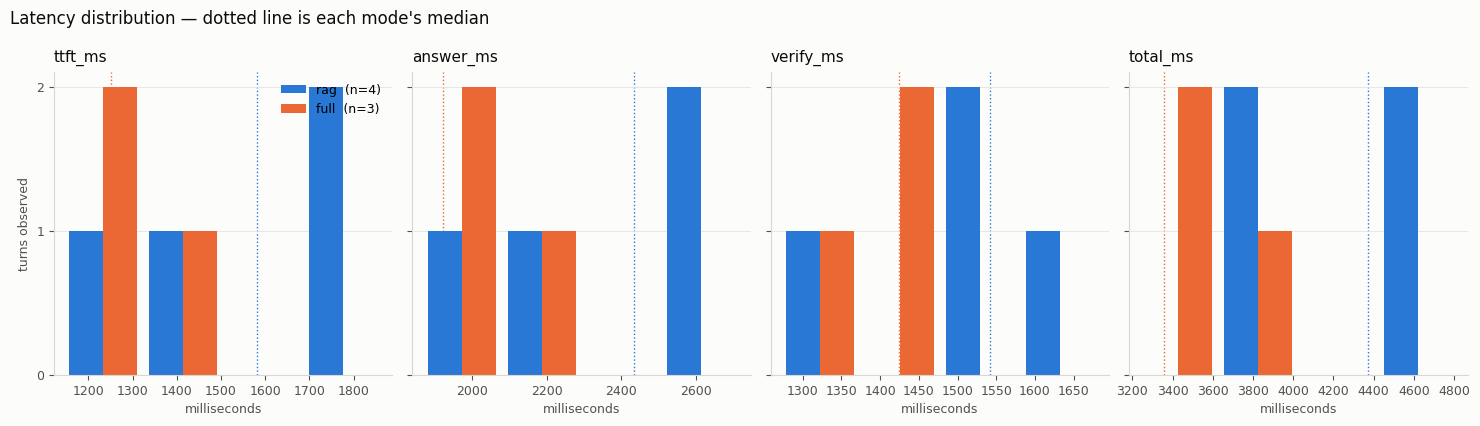

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

SURFACE, INK, INK_MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
C = {"rag": "#2a78d6", "full": "#eb6834"}

PLOT_STAGES = ["ttft_ms", "answer_ms", "verify_ms", "total_ms"]   # edit freely
BINS = "auto"        # or an int, e.g. 8, if the automatic binning is too coarse

fig, axes = plt.subplots(
    1, len(PLOT_STAGES), figsize=(3.7 * len(PLOT_STAGES), 4.3),
    facecolor=SURFACE, sharey=True,
)
axes = np.atleast_1d(axes)

for ax, stage in zip(axes, PLOT_STAGES):
    ax.set_facecolor(SURFACE)

    rag_v = df.loc[df["mode"] == "rag", stage].dropna().to_numpy()
    full_v = df.loc[df["mode"] == "full", stage].dropna().to_numpy()
    both = np.concatenate([rag_v, full_v])
    if not len(both):
        continue

    # One shared set of bin edges, so the two modes are directly comparable.
    edges = np.histogram_bin_edges(both, bins=BINS)

    # Side-by-side bars rather than overlapping translucent fills, which muddy
    # the colours where they cross and hide which series is on top.
    ax.hist([rag_v, full_v], bins=edges, rwidth=0.85,
            color=[C["rag"], C["full"]],
            label=[f"rag  (n={len(rag_v)})", f"full  (n={len(full_v)})"])

    # Where the middle sits, for reading the bars against.
    for mode, vals in (("rag", rag_v), ("full", full_v)):
        if len(vals):
            ax.axvline(np.median(vals), color=C[mode], linewidth=1,
                       linestyle=":", zorder=0)

    ax.set_title(stage, fontsize=11, color=INK, loc="left", pad=8)
    ax.set_xlabel("milliseconds", fontsize=9, color=INK_MUTED)
    ax.tick_params(colors=INK_MUTED, labelsize=9)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis="y", color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    # ax.set_xscale("log")   # uncomment when one outlier stretches the axis
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#d8d7d2")

axes[0].set_ylabel("turns observed", fontsize=9, color=INK_MUTED)
axes[0].legend(frameon=False, fontsize=9, loc="upper right")
fig.suptitle("Latency distribution — dotted line is each mode's median",
             fontsize=12, color=INK, x=0.005, ha="left")
plt.tight_layout()
plt.show()

## Reading the result honestly

**What would confirm the hunch:** `ttft_ms` and `answer_ms` clearly lower under `rag`, with
`retrieval_ms` small enough that `total_ms` still comes out ahead.

**What would disconfirm it:** `retrieval_ms` eating the whole stage-2 saving. That is a real
possible outcome at this doc size - 64 sections is small enough that the full document already
prefills fast, while retrieval still costs a full embedding round-trip. RAG's case here is
headroom and a separately scorable retrieval stage, not speed. If the numbers say it is not
faster, say so.

**Sanity checks before believing any of it:**

| Check | Expected | If it fails |
|---|---|---|
| `verify_ms` across modes | close | the run was noisy - add samples before drawing conclusions |
| `prompt_chars` for `rag` | far smaller than `full` | `USE_RAG` was not applied |
| `retrieval_ms` for `full` | near zero | something is retrieving when it should not be |
| Same gap after more samples | stable | if it moves more between runs than between modes, you are measuring the network |

Because the log accumulates, the cheapest way to firm up a shaky result is to add questions and
re-run - the summary widens its sample automatically rather than starting over.

**What this does not measure:** Streamlit rerun overhead, widget rendering, and session-state
handling. Those sit between these numbers and what you feel in the browser.

**One variable at a time.** Changing `RAG_TOP_K` and the answer model between runs produces a
number you cannot attribute to either. The log records both per row, and the summary filters to
the current `answer_model`, so a model switch starts a clean comparison instead of silently
blending two.